In [1]:
import pandas as pd

df = pd.read_csv('/content/loan_approval_dataset.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_valu

In [2]:
df.columns = [col.strip() for col in df.columns]
print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

Missing values per column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Number of duplicate rows: 0


In [4]:
print("Unique values and counts for 'education':")
print(df['education'].value_counts())

print("\nUnique values and counts for 'self_employed':")
print(df['self_employed'].value_counts())

print("\nUnique values and counts for 'loan_status':")
print(df['loan_status'].value_counts())

Unique values and counts for 'education':
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Unique values and counts for 'self_employed':
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

Unique values and counts for 'loan_status':
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


**Reasoning**:
To encode the target variable 'loan_status', I will map 'Approved' to 1 and 'Rejected' to 0 using the `replace()` method.



In [5]:
df['loan_status'] = df['loan_status'].replace({'Approved': 1, 'Rejected': 0})
print("Encoded 'loan_status' column:")
print(df['loan_status'].value_counts())

Encoded 'loan_status' column:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [6]:
df = pd.get_dummies(df, columns=['education', 'self_employed'], drop_first=True)
print("DataFrame after One-Hot Encoding:")
print(df.head())

DataFrame after One-Hot Encoding:
   loan_id  no_of_dependents  income_annum  loan_amount  loan_term  \
0        1                 2       9600000     29900000         12   
1        2                 0       4100000     12200000          8   
2        3                 3       9100000     29700000         20   
3        4                 3       8200000     30700000          8   
4        5                 5       9800000     24200000         20   

   cibil_score  residential_assets_value  commercial_assets_value  \
0          778                   2400000                 17600000   
1          417                   2700000                  2200000   
2          506                   7100000                  4500000   
3          467                  18200000                  3300000   
4          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value loan_status  education_ Not Graduate  \
0             22700000           8000000    Appro

In [8]:
df['loan_status'] = df['loan_status'].str.strip().replace({'Approved': 1, 'Rejected': 0}).astype(int)
print("Encoded 'loan_status' column with integer types:")
print(df['loan_status'].value_counts())

Encoded 'loan_status' column with integer types:
loan_status
1    2656
0    1613
Name: count, dtype: int64


/tmp/ipython-input-952452205.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_status'] = df['loan_status'].str.strip().replace({'Approved': 1, 'Rejected': 0}).astype(int)


In [9]:
X = df.drop(['loan_id', 'loan_status'], axis=1)
y = df['loan_status']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of features (X):")
print(X.head())

Features (X) shape: (4269, 11)
Target (y) shape: (4269,)
First 5 rows of features (X):
   no_of_dependents  income_annum  loan_amount  loan_term  cibil_score  \
0                 2       9600000     29900000         12          778   
1                 0       4100000     12200000          8          417   
2                 3       9100000     29700000         20          506   
3                 3       8200000     30700000          8          467   
4                 5       9800000     24200000         20          382   

   residential_assets_value  commercial_assets_value  luxury_assets_value  \
0                   2400000                 17600000             22700000   
1                   2700000                  2200000              8800000   
2                   7100000                  4500000             33300000   
3                  18200000                  3300000             23300000   
4                  12400000                  8200000             29400000   

   ba

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3415, 11)
X_test shape: (854, 11)
y_train shape: (3415,)
y_test shape: (854,)


In [11]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding the one-hot encoded boolean columns)
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns identified:", numerical_cols.tolist())

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on numerical features of X_train and transform them
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled_numerical = scaler.transform(X_test[numerical_cols])

# Convert scaled arrays back to DataFrame for better handling later
X_train_scaled_numerical_df = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols, index=X_train.index)
X_test_scaled_numerical_df = pd.DataFrame(X_test_scaled_numerical, columns=numerical_cols, index=X_test.index)

print("\nFirst 5 rows of scaled numerical features for X_train:")
print(X_train_scaled_numerical_df.head())

print("\nFirst 5 rows of scaled numerical features for X_test:")
print(X_test_scaled_numerical_df.head())

Numerical columns identified: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

First 5 rows of scaled numerical features for X_train:
      no_of_dependents  income_annum  loan_amount  loan_term  cibil_score  \
1675          1.512508      1.009500     1.624772  -0.860003    -0.187401   
1164         -1.435001      1.614171     2.077128   0.188894     0.637397   
192          -0.845499     -1.515891    -1.354157  -0.510371     0.474761   
910          -0.255997     -0.057566    -0.228784   1.237791     0.892968   
567           1.512508     -0.733375    -0.449445   0.188894    -0.925072   

      residential_assets_value  commercial_assets_value  luxury_assets_value  \
1675                 -0.255384                 2.046786             0.078083   
1164                  2.495693                 1.223111             2.498432   
192                  -0.805600   

In [12]:
boolean_cols = X_train.select_dtypes(include=['bool']).columns

# Extract boolean columns from original X_train and X_test
X_train_boolean = X_train[boolean_cols]
X_test_boolean = X_test[boolean_cols]

# Combine scaled numerical features with boolean features
X_train = pd.concat([X_train_scaled_numerical_df, X_train_boolean], axis=1)
X_test = pd.concat([X_test_scaled_numerical_df, X_test_boolean], axis=1)

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

print("\nFirst 5 rows of final preprocessed X_train:")
print(X_train.head())

print("\nFirst 5 rows of final preprocessed X_test:")
print(X_test.head())

Final X_train shape: (3415, 11)
Final X_test shape: (854, 11)

First 5 rows of final preprocessed X_train:
      no_of_dependents  income_annum  loan_amount  loan_term  cibil_score  \
1675          1.512508      1.009500     1.624772  -0.860003    -0.187401   
1164         -1.435001      1.614171     2.077128   0.188894     0.637397   
192          -0.845499     -1.515891    -1.354157  -0.510371     0.474761   
910          -0.255997     -0.057566    -0.228784   1.237791     0.892968   
567           1.512508     -0.733375    -0.449445   0.188894    -0.925072   

      residential_assets_value  commercial_assets_value  luxury_assets_value  \
1675                 -0.255384                 2.046786             0.078083   
1164                  2.495693                 1.223111             2.498432   
192                  -0.805600                -0.881836            -1.339239   
910                   0.111426                -0.378479             0.143498   
567                   0.157277

In [13]:
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Fit the model to the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.



--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       318
           1       0.92      0.93      0.93       536

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.91      0.91      0.91       854


--- Confusion Matrix ---
[[276  42]
 [ 38 498]]

AUC-ROC Score: 0.9674


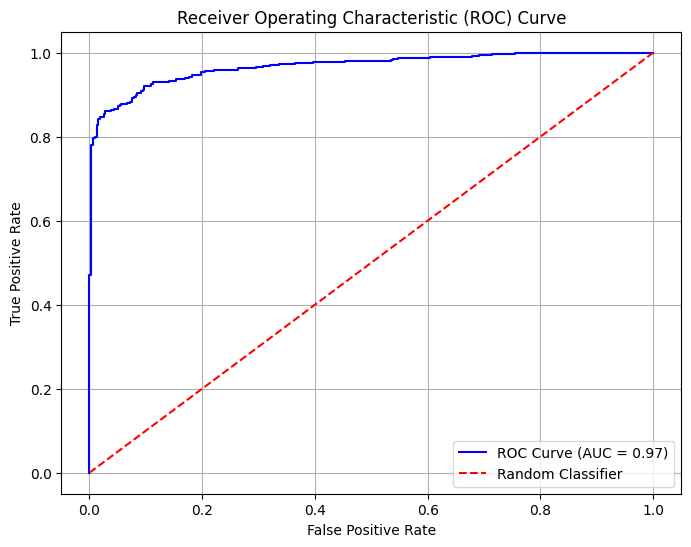

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Predict probabilities for the positive class (1)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC Score: {auc_roc:.4f}")

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_roc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()